In [113]:
from langgraph.graph import StateGraph,START,END
from transformers import pipeline 
from typing import TypedDict,Literal
from dotenv import load_dotenv 
from pydantic import BaseModel,Field 
from langchain_groq import ChatGroq
from langchain_groq import ChatGroq
from langchain_core.output_parsers import PydanticOutputParser
import os
os.environ["GROQ_API_KEY"] = "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"



In [114]:
load_dotenv()

True

In [115]:
from langchain_groq import ChatGroq

model = ChatGroq(
    model="llama-3.3-70b-versatile",  # or "mixtral-8x7b-32768"
    temperature=0.2,
)


In [116]:
#for structured output ->create a schema
class SentimentSchema(BaseModel):
    
    sentiment: Literal["positive","negative"]=Field(description='Sentiment of the review')


In [117]:
class DiagnosisSchema(BaseModel):
    issue_type: Literal["UX", "Performance", "Bug", "Support", "Other"] = Field(description="The category of issue mentioned in the review")
    tone: Literal["angry", "frustrated", "disappointed", "calm"] = Field(description="The emotional tone expressed by the user")
    urgency: Literal["low", "medium", "high"] = Field(description="How urgent or critical the issue appears to be")

In [118]:
structured_model = model.with_structured_output(SentimentSchema)
structured_model2 = model.with_structured_output(DiagnosisSchema)




In [119]:

class ReviewState(TypedDict):

    review:str
    sentiment: Literal["positive","negative"]
    diagnosis:dict
    response:str 

In [120]:
def find_sentiment(state: ReviewState):
    prompt = f"Determine sentiment (positive or negative) of this review:\n\n{state['review']}"
    result = structured_model.invoke(prompt)
    return {"sentiment": result.sentiment}


def check_sentiment(state: ReviewState) -> Literal["positive_response", "run_diagnosis"]:
    return "positive_response" if state["sentiment"] == "positive" else "run_diagnosis"


def positive_response(state: ReviewState):
    prompt = f"""
Write a warm appreciation message for this review:

"{state['review']}"

Also request the user to leave detailed feedback on our website.
"""
    response = model.invoke(prompt).content
    return {"response": response}


def run_diagnosis(state: ReviewState):
    prompt = f"""
Analyze this negative review and return:
issue_type, tone, urgency

Review: "{state['review']}"
"""
    result = structured_model2.invoke(prompt)
    return {"diagnosis": result.model_dump()}


def negative_response(state: ReviewState):
    diagnosis = state["diagnosis"]

    prompt = f"""
You are a customer support assistant.
The user experienced a '{diagnosis['issue_type']}' issue,
felt '{diagnosis['tone']}', and urgency is '{diagnosis['urgency']}'.

Write an empathetic response with steps you're taking to resolve the issue.
"""

    response = model.invoke(prompt).content
    return {"response": response}



In [121]:
graph = StateGraph(ReviewState)

graph.add_node("find_sentiment", find_sentiment)
graph.add_node("run_diagnosis", run_diagnosis)
graph.add_node("positive_response", positive_response)
graph.add_node("negative_response", negative_response)

graph.add_edge(START, "find_sentiment")
graph.add_conditional_edges("find_sentiment", check_sentiment)
graph.add_edge("positive_response", END)
graph.add_edge("run_diagnosis", "negative_response")
graph.add_edge("negative_response", END)

workflow = graph.compile()


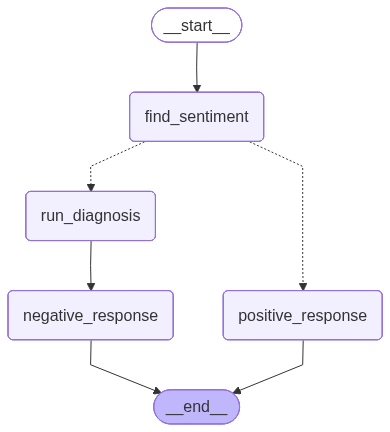

In [122]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())

In [123]:
initial_state = {
    "review": "The UI is confusing and it keeps crashing. Very frustrating experience.",
}

output = workflow.invoke(initial_state)
print(output)

{'review': 'The UI is confusing and it keeps crashing. Very frustrating experience.', 'sentiment': 'negative', 'diagnosis': {'issue_type': 'UX', 'tone': 'frustrated', 'urgency': 'high'}, 'response': "I'm so sorry to hear that you're experiencing a frustrating issue with our product, and I can imagine how urgent it must feel to get it resolved. I'm here to help and want to assure you that I'm taking immediate action to address the problem.\n\nFirst, I want to acknowledge your frustration and appreciate you taking the time to reach out to us. I understand that a poor user experience can be really disappointing, and I'm committed to making it right.\n\nTo resolve the issue, I'm going to escalate your case to our specialized team, who will work closely with me to investigate and fix the problem as quickly as possible. In the meantime, I'd like to ask a few questions to gather more information about what you're experiencing. This will help us to identify the root cause and provide a more ef